# Imports

In [2]:
import numpy as np
import pandas as pd
import glob
from pandas_plink import read_plink
import joblib
import subprocess
import warnings
import os
from sklearn.decomposition import PCA
import matplotlib as plt
import matplotlib.pyplot as plt

The human genome consists of DNA which is made up of four base pairs in specific combinations. A mutation that results in the change of the base pairs at a single location is known a SNP. SNPs are passed onto offispring, therefor individuals of shared ancestry are likely to carry the same mutation(SNP) at the same position in the genome. This allows for the identification of genetic relationships and the study of population history. Because these variants are inherited, researchers can use them as biological markers to trace lineages, estimate the degree of kinship between individuals, map the geographic origins of ancestors, and check for health markers like disease suceptability etc.
<br><br>
Two datasets are used here: 23andMe publicly accessible data which contains SNPs that are geared for consumer marketing and the 1240k academic dataset which contains deeper, more informative SNPs. The two are somewhat incompatable given their differing aims and the way the datasets are built. The aim of this projct is to see whether, with ML methods, the two can be bridged and some meaningful analysis can be done. Such as:<br>

1. Identifying which SNPs are linked to specific diseases or physical traits.<br>
2. Grouping individuals based on their genetic similarity to ensure accurate medical or ancestral studies.

# File Paths

In [35]:
plink_path = r"plink\plink1.9"
bim_path = r"reference_samples\v62_AADR_1240K.bim"
clean_snps_path = r"23andMe/snps_list_clean.txt"

# Get the 23AndMe SNPs List

In [17]:
# Read the Bim File which contains the SNPs
bim = pd.read_csv(bim_path, sep=r'\s+', header=None)

# Extract the columns
bim.columns = ["chr", "snp", "cm", "pos", "a1", "a2"]
print("1240k SNP count:", len(bim))

1240k SNP count: 1233013


# Intersect with 23andME

In [22]:
# Load the 23andME SNPs list
clean_snps = []
with open(clean_snps_path, "r") as f:
    for x in f:
        clean_snps = [line.strip() for line in f if line.strip()]

In [23]:
clean_snps[:5]

['rs11001766', 'rs7178822', 'rs2426273', 'rs10839591', 'rs7780514']

In [24]:
# Get the shared SNPs in both the 1240k dataset and the 23andMe datase
shared_snps = bim["snp"].isin(clean_snps)
shared_bim = bim[shared_snps].copy()

In [26]:
print("Shared SNPs:", len(shared_bim))

Shared SNPs: 667926


##### Shared SNPs is 667,926 which is pretty good

# Clean the List

In [ ]:
# Remove ambigous SNPs. These are SNPs where the alleles can look the same read forwards and backwards. Can't tell which is which with merged datasets.
# LD Prune. SNPs in a local region are likely to be inherited together leading to blocks of inherited SNPs which may be mostly redundant.
# Remove dublicate enteries.

In [27]:
ambiguous = {("A","T"),("T","A"),("C","G"),("G","C")}
shared_bim = shared_bim[~shared_bim[["a1","a2"]].apply(tuple, axis=1).isin(ambiguous)]

In [28]:
shared_bim = shared_bim.drop_duplicates("snp")

In [29]:
print("Shared SNPs:", len(shared_bim))

Shared SNPs: 666275


##### Shared SNPs has dropped to 666,275 which is still pretty good

In [ ]:
# LD-Prune with PLINK: .\plink1.9 --bfile reference_samples\v62_AADR_1240K --memory 800 --extract snps_list_clean.txt --make-bed --out reference_shared

In [42]:
bfile_loc = r"reference_shared\reference_shared"
out_prefix = r"reference_ldpruned"

cmd = [
    os.path.join(".", plink_path),
    "--bfile", bfile_loc,
    "--indep-pairwise", "200", "50", "0.2",
    "--out", out_prefix
]

subprocess.run(cmd, check=True)

CompletedProcess(args=['.\\plink\\plink1.9', '--bfile', 'reference_shared\\reference_shared', '--indep-pairwise', '200', '50', '0.2', '--out', 'reference_ldpruned'], returncode=0)

In [12]:
# Create the files with PLINK: .\plink1.9 --bfile reference_shared\reference_shared --split-x b37 --extract Ld-pruned\reference_ldpruned.prune.in --make-bed --out reference_shared_LD --memory 800

# Compute FST

SNP count is 275,525 after cleaning
Goal is to create a sub-list of informative SNPs
so calculate the 50k-100k SNPs that are most influential

The references for this section are:<br>
https://www.uwyo.edu/dbmcd/popecol/maylects/fst.html<br>
https://evomics.org/learning/population-and-speciation-genomics/2020-population-and-speciation-genomics/first-steps-in-genomic-data-analysis/#ex3.2<br>
https://bios1140.github.io/understanding-fst-the-fixation-index.html<br>
https://github.com/laneatmore/pairwise_fst/blob/main/pairwise_fst.py<br>
https://youtu.be/KiZn3Y0bNU8<br>
<br>
Fst is the measure of the variance. Given that our current count is 275,525, it would be best to create a subset. Not all of the 275,525 are going to be usefull. Fst will give the most influential SNPs responsible for the variation.<br><br>
It is calculated by:<br> <br>
F<sub>ST</sub>=$\frac{V_b}{V_t}$<br>
Where: <br><br>
1- V<sub>b</sub> = Variance between populations<br>
2- V<sub>t</sub> = Total variance<br><br>
1- The measure of how much the frequencies between populations differ the total mean<br>
2- This is the sum of V<sub>b</sub> and V<sub>w</sub> which is the variation within each population.<br><br>
p<sub>total</sub> = $\frac{∑ no. of alternate allels for individuals in all pops}{2 X N}$<br>
p<sub>pop</sub> = $\frac{∑ no. of alternate allels for individuals in each pop}{2 X N}$<br><br>
V<sub>b</sub> = $\frac{1}{m-1}$∑<sub>i=0</sub><sup>m</sup> N<sub>i</sub>(p<sub>pop i</sub>-p<sub>total i</sub>)<sup>2</sup><br>
V<sub>t</sub> = V<sub>b</sub> + V<sub>w</sub>

In [25]:
# Divide into chunks so as to not load the entirity into memory and exclude non-humans
def compute_fst(bfile_loc, pop_column="fid", exclude_list=None, chunk_size=1000, top_n=50000, output_csv="top_fst_snps.csv"):
    warnings.filterwarnings("ignore", category=RuntimeWarning) # Clean output
    print("Loading Data -->")

    bim, fam, bed = read_plink(bfile_loc) # Read the files
    
    # Exclude samples
    if exclude_list:
        exclude_list = set(exclude_list)

        exclude = ~(
            fam["iid"].isin(exclude_list) | # Exclude certain samples
            fam["fid"].isin(exclude_list)
        )

        print(f"No. before exclusion: {len(fam)}")
        fam = fam[exclude].reset_index(drop=True)
        bed = bed[:, exclude.values]
        print(f"No. after exclusion: {len(fam)}")

    # Labels
    pop_labels = fam[pop_column].values # Extract every label
    populations = np.unique(pop_labels) # Store only the unique population labels

    print(f"Populations detected: {len(populations)}")
    print(f"Total SNPs: {bed.shape[0]:,}")

    fst_results=[]
    
    # Compute fst
    for start in range(0, bed.shape[0], chunk_size): # Dived the data into chunks rather load it entirely for memory effeciency reasons
        end = min(start + chunk_size, bed.shape[0])
        print(f"Processing SNPs {start}–{end}") # Print for validation

        geno = bed[start:end, :].compute().astype(np.float32).T # For each chunk, get the matrix, transpose, also use float 32 for less memory usage
        snp_ids = bim.iloc[start:end]["snp"].values # Extract the SNP IDs for the current chunk
        # Transpose is necessary because the original file is orientated: SNPS,individuals
        # We want individual data

        # Calculate the frequency for each SNP
        # Each entery in geno is either
        # 0 representing AA
        # 1 representing AB
        # 2 representng BB
        # NaN
        # Each individual, for a given SNP, has one of the above as representation
        # The mean represents the average at that position for the whole dataset
        # Divide each by 2 to get the frequency since every individual has 2 alleles
        # It's a measure of how prevelant the less common variant is in a population
        p_bar = np.nanmean(geno, axis=0) / 2.0

        # Remove monomorphic SNPs
        # These are SNPs that show no variation across a population so are not informative
        # If there is no variation then the frequency will be either 1 or 0
        # So only include SNPs that show variation acrosss individuals
        valid = (p_bar > 0) & (p_bar < 1)
        if not np.any(valid):
            continue

        geno = geno[:, valid] # Drop non valid genotypes
        snp_ids = snp_ids[valid] # Drop the SNP-IDs associated with non-vlid genotypes
        p_bar = p_bar[valid] # Drop the non-valid frequency enteries

        # Population allele frequencies
        pop_freqs = []
        for pop in populations: # For every unique population label
            pop_geno = geno[pop_labels == pop] # Get the genotype for that population
            if pop_geno.shape[0] == 0: # If it's empty continue
                continue
            freq = np.nanmean(pop_geno, axis=0) / 2.0 # Otherwise calculate the SNP frequency for each population
            pop_freqs.append(freq) # Append to list

        pop_freqs = np.vstack(pop_freqs) # Stack the list

        var_p = np.nanvar(pop_freqs, axis=0) # Measure the variance at each position for each population across the frequencies
        # Calculate the total variance
        v_t = p_bar * (1 - p_bar)
        v_t[v_t == 0] = np.nan
        # Compute the fst
        fst = var_p / v_t
        # Store results
        fst_results.append(pd.DataFrame({"SNP": snp_ids,"FST": fst}))
    print("Combining the results -->")
    # Then combine the results and sort by order of the SNP with the highest FST
    fst_df = (pd.concat(fst_results).dropna().sort_values("FST", ascending=False).head(top_n))
    # Save results
    fst_df.to_csv(output_csv, index=False)
    print(f"Saved top {len(fst_df)} SNPs by FST")
    return fst_df

In [18]:
# Some samples are non-human: Neanderthal, Denisonvan, Gorilla, Chimp etc. so remove those since they will skew the variation.
exclude_list = ["Goyet_Neanderthal.SG","LesCottes_Neanderthal.SG", "Altai_Neanderthal.DG","DenisovaNeanderthalMix.SG","Mezmaiskaya2_Neanderthal.SG","Spy_Neanderthal.SG","VindijaG1_Neanderthal.SG","Altai_Neanderthal.DG","Ancestor.REF","CDX.SG","Chimp.REF","CHS.SG","Denisova.DG","Gorilla.REF","Href.REF","KHV.SG","ONG.SG","PEL.SG","RAJ.SG","She.DG","YRI_o.SG","Chagyrskaya_Neanderthal.DG",""]

aisnp_df = compute_fst(
    bfile_loc=r"ld-pruned\reference_shared_LD",
    pop_column="fid",
    exclude_list=exclude_list,
    chunk_size=20000,
    top_n=50000,
    output_csv="AISNP_top50k.csv"
)

#aisnp_df["SNP_ID"].to_csv("AISNP_top50k.txt", index=False, header=False)

Loading Data -->


Mapping files: 100%|█████████████████████████████████████████████████████████████████████| 3/3 [00:09<00:00,  3.15s/it]


No. before exclusion: 17629
No. after exclusion: 17573
Populations detected: 4281
Total SNPs: 275,525
Processing SNPs 0–20000
Processing SNPs 20000–40000
Processing SNPs 40000–60000
Processing SNPs 60000–80000
Processing SNPs 80000–100000
Processing SNPs 100000–120000
Processing SNPs 120000–140000
Processing SNPs 140000–160000
Processing SNPs 160000–180000
Processing SNPs 180000–200000
Processing SNPs 200000–220000
Processing SNPs 220000–240000
Processing SNPs 240000–260000
Processing SNPs 260000–275525
Combining the results -->
Saved top 50000 SNPs by FST


PCA maximises total variation whilst Fst maximises between population variation meaning it could ignore within population variance which is generally higher. So ML will be used to evaluate which performs best. PCA on the whole data or the subset.

# Fit PCA

In [42]:
warnings.filterwarnings("ignore", category =RuntimeWarning)

def compute_pca(file_loc, exclude_list=None, n_comp=20, pop_col="fid", output="ref_pca"):
    
    print("Loading Data -->")
    bim, fam, bed = read_plink(file_loc) # Load files

    # Get rid of the exclude list samples
    if exclude_list:
        exclude_list = set(exclude_list)

        exclude = ~(
            fam["iid"].isin(exclude_list) | # Exclude certain samples
            fam["fid"].isin(exclude_list)
        )

        print(f"No. before exclusion: {len(fam)}")
        fam = fam[exclude].reset_index(drop=True)
        bed = bed[:, exclude.values]
        print(f"No. after exclusion: {len(fam)}")

    # load the data
    print("loading the data -->")
    X = bed.compute().astype(np.float32).T # Use float 32 for less memory usage. Also, transpose to get {individual, SNP}
    print(f"length of array = {len(X)}")
    
    # Remove columns that have large missing enteries
    print("Removing columns that have large missing enteries -->")
    missing = np.mean(np.isnan(x), axis=0) # Get the boolean state of each column
    valid_snps = missing < 0.05
    X = X[:, valid_snps] # Keep columns with less than 5% missing values
    bim = bim.iloc[valid_snps].reset_index(drop=True)
    print(f"length of array = {len(X)}")

    # Impute remaining missing values
    # If for the remaining data there are still missing values impute with the mean
    print("Imputing remaining missing values -->")
    snp_mean = np.mean(X, axis=0)
    inds,snps = np.where(np.isnan(X))
    X[inds,snps]=snp_mean[snps]

    # Compute the z score
    # This gives each component an equal weighting
    print("standardising data -->")
    std = np.std(x, axis=0)
    X_std = (X - snp_mean)/std

    # Fit PCA
    print("Fitting PCA -->")
    p = PCA
    pca = p(n_components=n_comp, svd_solver="randomized")
    pcs = pca.fit_transform(X_std)
    print("Complete.")
   
    # Evaluate
    print(f"Here are the variance ratio for each component{pca.explaine_variance_ratio_}")

    # Save the files
    joblib.dump(pca, f"{output}_model.joblib")
    np.save(f"{output}_means.npy", snp_mean)
    np.save(f"{output}_std.npy", std)
    
    bim["snp"].to_csv(f"{output_prefix}_snps.txt", index=False, header=False)
    pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(n_components)]).assign(IID=fam["iid"].values, FID=fam["fid"].values).to_csv(f"{output_prefix}_scores.csv", index=False)

    print("PCA Saved Successfully!!")
    return pca, pcs, fam, bim

In [ ]:
# Some samples are non-human: Neanderthal, Denisonvan, Gorilla, Chimp etc. so remove those since they will skew the variation.
exclude_list = ["Goyet_Neanderthal.SG","LesCottes_Neanderthal.SG", "Altai_Neanderthal.DG","DenisovaNeanderthalMix.SG","Mezmaiskaya2_Neanderthal.SG","Spy_Neanderthal.SG","VindijaG1_Neanderthal.SG","Altai_Neanderthal.DG","Ancestor.REF","CDX.SG","Chimp.REF","CHS.SG","Denisova.DG","Gorilla.REF","Href.REF","KHV.SG","ONG.SG","PEL.SG","RAJ.SG","She.DG","YRI_o.SG","Chagyrskaya_Neanderthal.DG",""]

pca_df = compute_pca(
    file_loc=r"ld-pruned\reference_shared_LD",
    exclude_list=exclude_list,
    n_comp=20,
    output="ref_pca",
    chunk_size=20000
)


In [44]:
# PLINK: .\plink2 --bfile Ld-pruned\reference_shared_LD --remove exclude_list.txt --pca 15 approx allele-wts --threads 2 --memory 2500 --out ref_pca

# Check the PCA

In [3]:
pca_result = np.loadtxt("plink/ref_pca.eigenval")
# percentage is equal to the value of each PC / the sum
pc_sum = pca_result.sum()
variance_ratio = pca_result/pc_sum

for n, p in enumerate(variance_ratio):
    print(f"Here are the variance ratio for each component:\n{n} = {p*100:.2f}%")

Here are the variance ratio for each component:
0 = 41.18%
Here are the variance ratio for each component:
1 = 28.17%
Here are the variance ratio for each component:
2 = 8.70%
Here are the variance ratio for each component:
3 = 4.40%
Here are the variance ratio for each component:
4 = 3.58%
Here are the variance ratio for each component:
5 = 3.15%
Here are the variance ratio for each component:
6 = 2.02%
Here are the variance ratio for each component:
7 = 1.78%
Here are the variance ratio for each component:
8 = 1.50%
Here are the variance ratio for each component:
9 = 1.37%
Here are the variance ratio for each component:
10 = 1.30%
Here are the variance ratio for each component:
11 = 0.84%
Here are the variance ratio for each component:
12 = 0.78%
Here are the variance ratio for each component:
13 = 0.61%
Here are the variance ratio for each component:
14 = 0.61%


In [4]:
pca_vec = pd.read_csv("plink/ref_pca.eigenvec", delim_whitespace=True)
#pca_vec.head(5)
pca_vec.iloc[11500:11550]

C:\Users\sindi\AppData\Local\Temp\ipykernel_14316\323509005.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca_vec = pd.read_csv("plink/ref_pca.eigenvec", delim_whitespace=True)


,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
11500,Miao.DG,HGDP01197.DG,-0.002613,0.021095,0.014135,0.010516,-0.000259,-0.004541,-0.001090,0.008423,0.001136,-0.013688,0.008960,0.005295,-0.001391,-0.000169,-0.000069
11501,Miao.DG,HGDP01198.DG,-0.002829,0.021074,0.013646,0.009384,0.000148,-0.002844,-0.002544,0.008965,0.001087,-0.015215,0.008483,0.005376,-0.003896,-0.000221,-0.001175
11502,Mixe.DG,B_Mixe-1.DG,-0.004495,0.018078,-0.036829,0.000529,0.008071,0.002812,-0.000028,0.008514,0.001105,-0.010715,0.005518,-0.025468,0.023522,0.002405,0.000721
11503,Mixe.DG,S_Mixe-2.DG,-0.004357,0.017808,-0.036834,0.000436,0.008229,0.003763,-0.000801,0.008199,0.001079,-0.010561,0.005578,-0.024985,0.024853,0.002464,0.000445
11504,Mixe.DG,S_Mixe-3.DG,-0.004091,0.017843,-0.037293,0.000156,0.008071,0.004035,0.000638,0.008718,0.000227,-0.011795,0.005908,-0.024903,0.024076,0.004309,0.001120
11505,Mixtec_1.DG,S_Mixtec-1.DG,-0.003638,0.016278,-0.034406,0.000206,0.007290,0.003453,0.000875,0.007794,0.001072,-0.009869,0.005434,-0.024868,0.023236,0.002290,0.000772
11506,Mixtec_2.DG,S_Mixtec-2.DG,-0.003154,0.010946,-0.026790,0.000474,0.006054,0.002953,0.001598,0.006307,0.002320,-0.006650,0.007036,-0.021248,0.015893,0.001596,-0.000299
11507,Mongola.DG,S_Mongola-2.DG,-0.002903,0.018799,0.009806,0.008857,-0.001264,-0.006689,-0.014443,0.000741,0.000705,0.002949,0.005083,-0.003508,0.005983,0.008469,0.005907
11508,Mongola.DG,S_Mongola-1.DG,-0.002874,0.018918,0.009786,0.008525,-0.001868,-0.005998,-0.011558,0.003231,0.001755,0.000069,0.005433,-0.002629,0.005388,0.011631,0.005750
11509,Mongola.DG,HGDP01223.DG,-0.002987,0.019285,0.010138,0.009062,-0.001254,-0.006960,-0.014944,0.000942,0.000583,0.002645,0.005104,-0.003769,0.006397,0.008904,0.006308


# Exploratory Evaluation

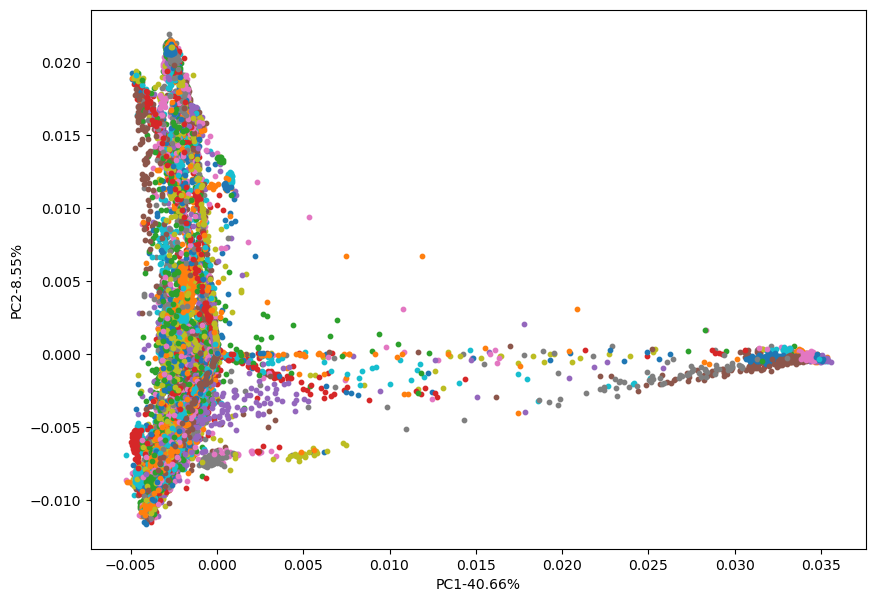

In [5]:
plt.figure(figsize=(10,7))
for pop in pca_vec["#FID"].unique():
    sub = pca_vec[pca_vec["#FID"]==pop]
    plt.scatter(sub["PC1"],sub["PC2"], label=pop, s=10)
plt.xlabel("PC1-41.18%")
plt.ylabel("PC2-28.17%")
#plt.legend()
plt.show()

In [ ]:
MAX_PER_POP = 1

plt.figure(figsize=(10, 7))
for pop in pca_vec["#FID"].unique():
    sub = pca_vec[pca_vec["#FID"] == pop]
    if len(sub) > MAX_PER_POP:
        sub_limited = sub.sample(n=MAX_PER_POP, random_state=42)
    else:
        sub_limited = sub
    plt.scatter(sub_limited["PC1"], sub_limited["PC2"], label=pop, s=10, alpha=0.6)
plt.xlabel("PC1-40.66%")
plt.ylabel("PC2-8.55%")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_vec, x="PC1", y="PC2", hue="#FID", s=15, legend=False)
plt.legend()
plt.show()

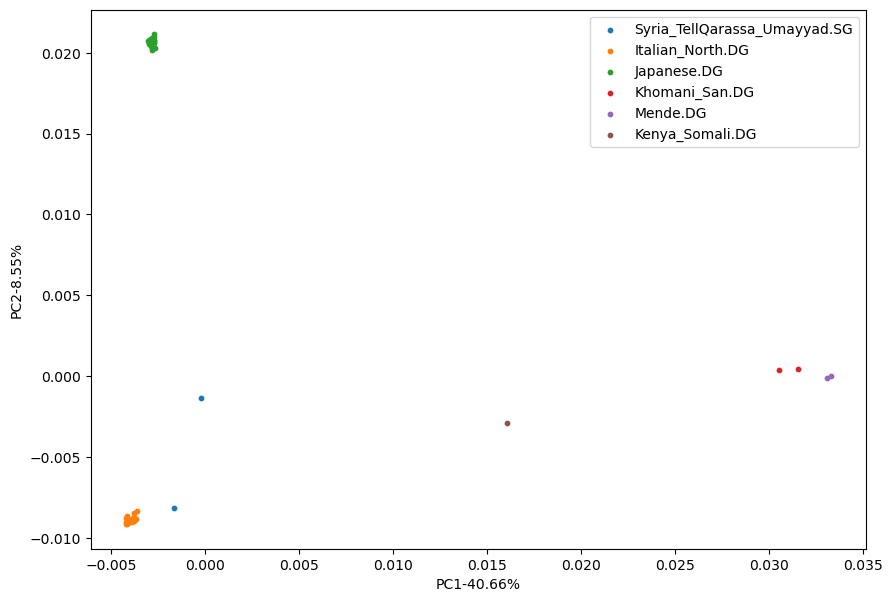

In [89]:
keep = ["Mende.DG","Kenya_Somali.DG","Syria_TellQarassa_Umayyad.SG","Italian_North.DG","Japanese.DG","Khomani_San.DG"] 
plt.figure(figsize=(10,7))
for pop in pca_vec["#FID"].unique():
    if pop in keep:
        sub = pca_vec[pca_vec["#FID"]==pop]
        plt.scatter(sub["PC1"],sub["PC2"], label=pop, s=10)
plt.xlabel("PC1-40.66%")
plt.ylabel("PC2-8.55%")
plt.legend()
plt.show()

In [87]:
keep = ["Mende.DG","Kenya_Somali.DG","Syria_TellQarassa_Umayyad.SG","Italian_North.DG","Japanese.DG","Khomani_San.DG"] 
a = input().strip()
print("Enter population")

if a in keep:
    print("True")
else:
    print("False")

 Mende.DG


Enter population
True
